In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
os.environ["CORRFUNC_USE_AVX512"] = "0"
os.environ["CORRFUNC_USE_AVX2"] = "0"
os.environ["CORRFUNC_USE_AVX"] = "0"
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
import astropy.units as u
import healpy as hp
from joblib import Parallel, delayed
import argparse
import configparser
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy import integrate
import astropy.constants as const

In [2]:
def parse_config():    
    parser = argparse.ArgumentParser()    
    parser.add_argument('--config', required=True)    
    args = parser.parse_args(["--config", "config.ini"])
    config = configparser.ConfigParser() 
    config.read(args.config) 
    return config
    
def make_clean():    
    global galaxy_csv_name, GW_csv_name, GW_data_size, galaxy_data_size, redshift_min, redshift_bin_size, luminosity_bin_min, luminosity_bin_size, theta_max, nside, z_bin_num, d_L_bin_num, r2dr, nthreads
    galaxy_csv_name = config['Config'].get('galaxy_csv_name')
    GW_csv_name = config['Config'].get('GW_csv_name')
    GW_data_size = config['Config'].getint('GW_data_size')    
    galaxy_data_size = config['Config'].getint('galaxy_data_size')    
    redshift_min = config['Config'].getfloat('redshift_min')    
    redshift_bin_size = config['Config'].getfloat('redshift_bin_size')
    luminosity_bin_min = config['Config'].getfloat('luminosity_bin_min')
    luminosity_bin_size = config['Config'].getfloat('luminosity_bin_size')
    theta_max = config['Config'].getfloat('theta_max')
    nside = config['Config'].getint('nside')
    z_bin_num = config['Config'].getint('z_bin_num')
    d_L_bin_num = config['Config'].getint('d_L_bin_num')
    r2dr = config['Config'].getint('random_2_data_ratio')
    nthreads = config['Config'].getint('nthreads')

In [3]:
#get variables from config file
config = parse_config()
make_clean()

In [4]:
#csv data
galaxy_df_full = pd.read_csv(galaxy_csv_name)
GW_df_full = pd.read_csv(GW_csv_name)

In [5]:
#testing parameters
if GW_data_size > len(GW_df_full):
    raise ValueError("GW_data_size too big. Input must be <=", len(GW_df_full))
if int(GW_data_size) != GW_data_size or GW_data_size < 1:
    raise ValueError("GW_data_size must be a positive integer")
if galaxy_data_size > len(galaxy_df_full):
    raise ValueError("galaxy_data_size too big. Input must be <=", len(galaxy_df_full))
if int(galaxy_data_size) != galaxy_data_size or galaxy_data_size < 1:
    raise ValueError("galaxy_data_size must be a positive integer")
if redshift_min < 0:
    raise ValueError("redshift_min must be positive")
if redshift_bin_size < 0:
    raise ValueError("redshift_bin_size must be positive")
if luminosity_bin_min < 0:
    raise ValueError("luminosity_bin_min must be positive")
if luminosity_bin_size < 0:
    raise ValueError("luminosity_bin_size must be positive")
if theta_max < 0:
    raise ValueError("theta_max must be positive")
if nside <= 0 or (nside & (nside - 1)) != 0:
    raise ValueError("nside must be a power of 2")
if int(z_bin_num) != z_bin_num or z_bin_num < 1:
    raise ValueError("z_bin_num must be a positive integer")
if int(d_L_bin_num) != d_L_bin_num or d_L_bin_num < 1:
    raise ValueError("d_L_bin_num must be a positive integer")
if r2dr < 1:
    raise ValueError("r2dr must be larger than 1")

In [6]:
#random sample of GW and galaxy data sets
GW_df_indices = np.random.choice(len(GW_df_full), GW_data_size, replace=False)
GW_df = GW_df_full.iloc[GW_df_indices]
galaxy_df_indices = np.random.choice(len(galaxy_df_full), galaxy_data_size, replace=False)
galaxy_df = galaxy_df_full.iloc[galaxy_df_indices]

In [7]:
#defines the redshift bin for an iteration
def redshift_bin(i):
    z_min = redshift_min + i * redshift_bin_size
    z_max = z_min + redshift_bin_size
    z_bin = galaxy_df[galaxy_df['redshift'] > z_min]
    z_bin = z_bin[z_bin['redshift'] < z_max]
    return z_bin

In [8]:
#defines the luminosity distance bin for an iteration
def luminosity_distance_bin(i):
    d_L_min = luminosity_bin_min + i * luminosity_bin_size
    d_L_max = d_L_min + luminosity_bin_size
    filtered_GW = GW_df[GW_df['luminosity distance'] < d_L_max]
    filtered_GW = filtered_GW[filtered_GW['luminosity distance'] > d_L_min]
    d_L_bin = filtered_GW
    return d_L_bin

In [9]:
#creates an array of ra and dec values the length of num
def random_func(num):
    ra_random = np.random.uniform(0,360,num)
    u = np.random.uniform(-1,1,num)
    dec_random = np.degrees(np.arcsin(u))
    random_coords = np.array([np.array(ra_random),np.array(dec_random)])
    return random_coords

In [10]:
#creates bins using the random dataset that is proportional to the size of the "real" dataset
def random_bins(random_coords, bin_size):
    random_indices = np.random.choice(len(random_coords[0]), bin_size, replace=False)

    random_ra = random_coords[0][random_indices]
    random_dec = random_coords[1][random_indices]
    random_coords_filtered = np.array([random_ra, random_dec])
    return random_coords_filtered

In [11]:
#cross correlation function
def dd_rr_func(theta_bin, galaxy, GW):
    galaxy_ra, galaxy_dec = galaxy
    GW_ra, GW_dec = GW
    dd_rr = DDtheta_mocks(
        autocorr=0,
        nthreads=nthreads, 
        binfile=theta_bin,
        RA1=galaxy_ra,
        DEC1=galaxy_dec,
        RA2=GW_ra,
        DEC2=GW_dec
    )
    return dd_rr

In [12]:
#normalizes dd and rr based on the bin sizes
def norm(dd, rr, z_bin, d_L_bin):
    dd_norm = dd['npairs'] / (len(z_bin) * len(d_L_bin))
    rr_norm = rr['npairs'] / (r2dr * len(z_bin) * r2dr * len(d_L_bin))
    return dd_norm, rr_norm

#Peebles-Hauser estimator
def w_func(dd_norm, rr_norm):
    w = (dd_norm / rr_norm) - 1
    return w

In [13]:
#w calculation without jackknife estimate
def w_no_jk(z_bin, d_L_bin, all_data):
    galaxy, GW, galaxy_random, GW_random = all_data
    dd = dd_rr_func(theta_bin, galaxy, GW)
    rr = dd_rr_func(theta_bin, galaxy_random, GW_random)
    dd_norm, rr_norm = norm(dd, rr, z_bin, d_L_bin)
    w = w_func(dd_norm, rr_norm)
    return w

In [14]:
#assigns healpix regions
def assign_healpix_region(ra_deg, dec_deg):
    theta = np.radians(90.0 - dec_deg)  # co-latitude
    phi = np.radians(ra_deg)            # longitude
    return hp.ang2pix(nside, theta, phi)

In [15]:
#assigns region numbers to each data point based on the nside resolution
def regions(coords):
    ra, dec = coords
    assigned_regions = assign_healpix_region(ra, dec)
    return assigned_regions

In [16]:
#masks the data by removing one region
def masking(coords, region, i):
    ra, dec = coords

    mask = region != i

    sample_ra = ra[mask]
    sample_dec = dec[mask]
    sample = np.array([sample_ra, sample_dec])
    return sample

In [17]:
#performs the w calculation after removing one region at a time, returns the w value without jackknife if no points are found in the region
def jk_loop(all_data, all_regions, i, w0):
    galaxy, GW, galaxy_random, GW_random = all_data
    galaxy_regions, GW_regions, galaxy_random_regions, GW_random_regions = all_regions

    if i in galaxy_regions or i in GW_regions:
        galaxy_sample = masking(galaxy, galaxy_regions, i)
        GW_sample = masking(GW, GW_regions, i)
        galaxy_random_sample = masking(galaxy_random, galaxy_random_regions, i)
        GW_random_sample = masking(GW_random, GW_random_regions, i)

        galaxy_random_ra, galaxy_random_dec = galaxy_random_sample
    
        dd = dd_rr_func(theta_bin, galaxy_sample, GW_sample)
        rr = dd_rr_func(theta_bin, galaxy_random_sample, GW_random_sample)
    
        dd_norm, rr_norm = norm(dd, rr, galaxy_sample[0], GW_sample[0])
        w = w_func(dd_norm, rr_norm)
    else:
        w = w0
    return w

In [18]:
#runs the jk_loop function and calculates the mean and variance from the results
def jackknife(all_data, all_regions, w0):
    galaxy, GW, galaxy_random, GW_random = all_data
    galaxy_regions, GW_regions, galaxy_random_regions, GW_random_regions = all_regions

    n_regions = len(galaxy_regions)

    jackknife_ws = Parallel(n_jobs=1)(
        delayed(jk_loop)(all_data, all_regions, i, w0) for i in range((nside**2)*12)
    )
    
    jackknife_mean = np.nanmean(jackknife_ws)
    jackknife_variance = ((n_regions - 1) / n_regions) * np.sum((jackknife_ws - jackknife_mean) ** 2)
    return jackknife_variance

In [19]:
#returns the w value and jackknife variance for pair of a redshift bin and a luminosity distance bin
def run_code(z_iter, d_L_iter):
    z_bin = redshift_bin(z_iter)
    d_L_bin = luminosity_distance_bin(d_L_iter)
    galaxy_ra, galaxy_dec = np.array(z_bin["RA_deg"]), np.array(z_bin["Dec_deg"])
    galaxy = np.array([galaxy_ra, galaxy_dec])
    GW_ra, GW_dec = np.array(d_L_bin["RA_deg"]), np.array(d_L_bin["Dec_deg"])
    GW = np.array([GW_ra, GW_dec])

    galaxy_random = random_bins(all_galaxy_random, len(z_bin)*r2dr)
    GW_random = random_bins(all_GW_random, len(d_L_bin)*r2dr)

    inputs = [galaxy, GW, galaxy_random, GW_random]
    results = Parallel(n_jobs=4)(delayed(regions)(data) for data in inputs)
    galaxy_regions, GW_regions, galaxy_random_regions, GW_random_regions = results

    all_data = [galaxy, GW, galaxy_random, GW_random]
    all_regions = [galaxy_regions, GW_regions, galaxy_random_regions, GW_random_regions]
    
    w = w_no_jk(z_bin, d_L_bin, all_data)
    var = jackknife(all_data, all_regions, w)
    return w, var

In [20]:
print(len(GW_df))
print(len(galaxy_df))

5000
100000


In [21]:
%%time
ws = []
variances = []

#establishes the theta bin for the cross correlation function
theta_max_deg = np.degrees(theta_max)
theta_bin = np.array([0.0, theta_max_deg])

galaxy_size = len(galaxy_df)
GW_size = len(GW_df)

#establishes the random datasets
galaxy_ra_random, galaxy_dec_random = random_func(galaxy_size*r2dr)
GW_ra_random, GW_dec_random = random_func(GW_size*r2dr)
all_galaxy_random = np.array([galaxy_ra_random, galaxy_dec_random])
all_GW_random = np.array([GW_ra_random, GW_dec_random])

#loops the run_code function over all pairs of redshift bins and luminosity distance bins
for d_L_iter in range(d_L_bin_num):
    for z_iter in range(z_bin_num):
        w, var = run_code(z_iter, d_L_iter)
        ws.append(w)
        variances.append(var)
        print(z_iter + 1, "/", z_bin_num)
    print(d_L_iter + 1, "/", d_L_bin_num)

print(ws)
print(len(ws))
print(variances)
print(len(variances))

[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
1 / 6
1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
2 / 6
1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
3 / 6
1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
4 / 6
1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
5 / 6
1 / 20
2 / 20
3 / 20
4 / 20
5 / 20
6 / 20
7 / 20
8 / 20
9 / 20
10 / 20
11 / 20
12 / 20
13 / 20
14 / 20
15 / 20
16 / 20
17 / 20
18 / 20
19 / 20
20 / 20
6 / 6
[array([-1.]), array([1.01342282]), array([0.32625995]), a

In [22]:
stdevs = np.sqrt(variances)

In [23]:
#finds the true means of the redshift and luminosity distance for each d_L bin
z_means = []
d_L_means = []
for d_L_iter in range(d_L_bin_num):
    d_L_bin = luminosity_distance_bin(d_L_iter)
    z_mean = np.mean(d_L_bin['redshift'])
    z_means.append(z_mean)
    d_L_mean = np.mean(d_L_bin['luminosity distance'])
    d_L_means.append(d_L_mean)

print(z_means)
print(d_L_means)

[np.float64(0.06854791715910445), np.float64(0.1071075498113551), np.float64(0.14521356240050515), np.float64(0.18073552729498685), np.float64(0.21619353895547921), np.float64(0.25057205142502814)]
[np.float64(319.2517469845396), np.float64(511.75004988753363), np.float64(710.7853981784181), np.float64(903.8964682933007), np.float64(1103.583104185031), np.float64(1303.5675809336235)]


In [24]:
#splits w and stdevs into the different d_L bins
split_w = np.array_split(np.array(ws),d_L_bin_num)
split_stdevs = np.array_split(np.array(stdevs),d_L_bin_num)

In [25]:
#finds factors closest to the square root of the input number (used to make the subplots look better)
def find_factors(num):
    sqrt_num = np.sqrt(num)
    if sqrt_num % 1 == 0:
        high_factor = int(sqrt_num)
        low_factor = int(sqrt_num)
    else:
        low_num = num // sqrt_num
        while num % low_num != 0:
            low_num = low_num - 1
        low_factor = int(low_num)
        high_factor = int(num / low_factor)
    return low_factor, high_factor

In [26]:
#defines gaussian
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

1.0373737806981431
[ 5  7  9 12 16]
1.5207740066119222
[ 3  6  8 10 12 15 18]
0.9374597993614335
[ 6 10 16]
1.164743431350985
[ 3  5 11 16]
1.014912917988312
[ 2  4  6  9 13]
1.2132594948059099
[ 3  5  7 11 16]


/tmp/ipykernel_4170/3180456389.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, x_data, y_data, sigma=y_error, absolute_sigma=True, p0 = [A0, mu0, redshift_bin_size])


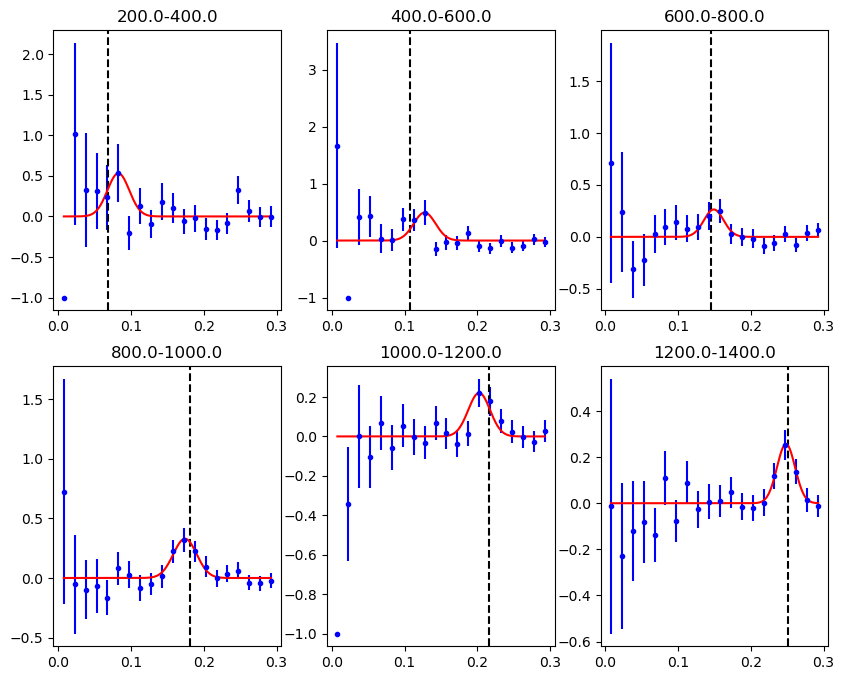

In [70]:
#each subplot is a d_L bin and graphs the w value for each redshift bin with a gaussian fit
z_min = redshift_min + redshift_bin_size/2
z_max = redshift_min + z_bin_num * redshift_bin_size - redshift_bin_size/2
z_values = np.array(np.linspace(z_min,z_max,z_bin_num))
sp_rows, sp_columns = find_factors(d_L_bin_num)
fig,axs = plt.subplots(sp_rows,sp_columns,figsize=(10,8))
z_means_est = []
stdev_est = []

for m in range(sp_rows):
    for n in range(sp_columns):
        i = m*sp_columns + n
        d_L_min = luminosity_bin_size*i+luminosity_bin_min
        d_L_max = d_L_min + luminosity_bin_size
        title = str(d_L_min) + "-" + str(d_L_max)
        x_data = z_values
        y_data = np.ravel(split_w[i])
        y_error = split_stdevs[i]
        z_mean = z_means[i]

        #y_smooth = savgol_filter(y_data, 9, 2)
        #start_cut = 0
        #peaks, _ = find_peaks(y_smooth[start_cut:], prominence=0.1)
        #peak_idx = start_cut + peaks[np.argmax(y_smooth[start_cut:][peaks])]

        inverse_error = np.where(y_error>0)
        #print(inverse_error)
        z_stdev = np.std((y_data[inverse_error] - np.average(y_data[inverse_error]))/y_error[inverse_error])
        print(z_stdev)
        
        peaks, _ = find_peaks(y_data, height=None, prominence=[0, z_stdev])
        print(peaks)
        peak_idx = peaks[np.argmax(y_data[peaks])]
        mu0 = x_data[peak_idx]
        #print(x_data[np.argmax(y_data)],mu0,x_data[peaks])
        A0 = y_data[peak_idx]

        popt, pcov = curve_fit(gaussian, x_data, y_data, sigma=y_error, absolute_sigma=True, p0 = [A0, mu0, redshift_bin_size])
        A_fit, mu_fit, sigma_fit = popt
        z_means_est.append(mu_fit)
        stdev_est.append(abs(sigma_fit))
        g_x_fit = np.linspace(min(x_data), max(x_data), 500)
        g_y_fit = gaussian(g_x_fit, *popt)
        
        axs[m,n].errorbar(x_data, y_data, yerr=y_error, fmt='.', color='b')
        axs[m,n].axvline(z_mean,linestyle='--',color='k')
        axs[m,n].plot(g_x_fit, g_y_fit, label='Gaussian fit', color='r')
        axs[m,n].set_title(title)

In [28]:
def lum_dist(z, H0, Omega_m=0.307115):
    def integrand(zp):
        return 1.0 / np.sqrt(1.0 - Omega_m + Omega_m * (1.0 + zp) ** 3)
    integrals = np.array([integrate.quad(integrand, 0, zz)[0] for zz in z])
    dL = (c_kms * (1.0 + z) / H0) * integrals
    return dL

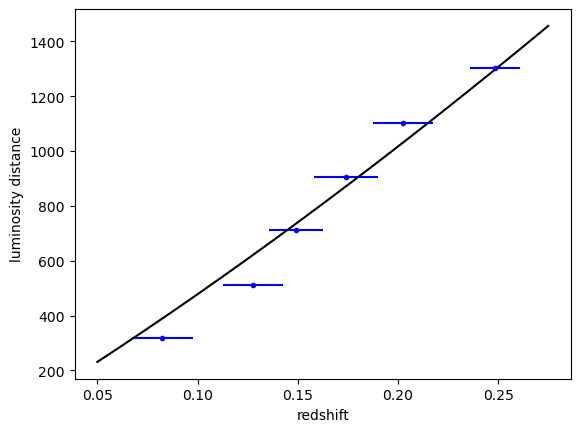

Fit results:
H_0     = 67.423 ± 0.032
[np.float64(0.015), np.float64(0.015), np.float64(0.013537824218465543), np.float64(0.016104761155890608), np.float64(0.015), np.float64(0.012461824000113567)]


In [68]:
c_kms = const.c.to('km/s').value

d_L_repeat = np.reshape(np.repeat(d_L_means, 10, axis=None), (len(z_means_est),-1))

popt, pcov = curve_fit(lum_dist, z_means_est, d_L_means, p0=[70], absolute_sigma=True)
H_fit = popt[0]
perr = np.sqrt(np.diag(pcov))
x_fit = np.linspace(0.05, 0.275, 500)
y_fit = lum_dist(x_fit, *popt)

plt.errorbar(z_means_est, d_L_means, xerr=stdev_est, fmt='.', color='b')
plt.plot(x_fit, y_fit, label="linear fit", color='k')
plt.xlabel("redshift")
plt.ylabel("luminosity distance")
plt.show()

print(f"Fit results:")
print(f"H_0     = {H_fit:.3f} ± {perr[0]:.3f}")
print(stdev_est)